**Python Individual Coursework : Study of Telecom dataset**

In [1]:
# Import all the necessary libraries
import numpy as np                                    # NUMPY library
import pandas as pd                                   # Pandas Library
import matplotlib.pyplot as plt                       # Matplotlib Library
import seaborn as sns                                 # Seaborn Library
from sklearn.preprocessing import StandardScaler      #StandardScalar Module
from sklearn.preprocessing import MinMaxScaler        #MinMaxScalar Module
from sklearn.preprocessing import LabelEncoder        #Label Encoder
from sklearn.model_selection import train_test_split  # Test Train Split
from sklearn.ensemble import RandomForestClassifier   # Random Forest CLassifier
from sklearn.metrics import classification_report     # Classification Report
from sklearn.metrics import confusion_matrix          # Confusion MAtrix
from sklearn.cluster import KMeans


Analysis Of Data Set

In [2]:
df_telecom = pd.read_csv("telecom.csv")
null_counts = df_telecom.isnull().sum()

# Check the count of blank (empty string) values in all columns
blank_counts = (df_telecom == '').sum()

# Combine both null and blank counts
total_null_blank_counts = null_counts + blank_counts
columns_with_nulls = total_null_blank_counts[total_null_blank_counts > 0]
print(columns_with_nulls)


Offer            3877
Internet Type    1526
Churn Reason     5174
dtype: int64


Understanding of Data Set to find out the Continous and Categorical Columns for further research

In [3]:
# Separate numerical and categorical columns
numerical_cols = df_telecom.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_telecom.select_dtypes(include=['object', 'category']).columns



We can read Numerical columns and categorical columns to have a full one screen visual about the type of data in all the columns , keeping the display code commented to avoid unnecssesary output

In [4]:
# Summarize numerical columns
# print("Numerical Column Summary:")
# print(df_telecom[numerical_cols].describe())

# Summariz categorical columns
# print("\nCategorical Column Value Counts:")
# for col in categorical_cols:
#     print(f"\n{col} Value Counts:")
#     print(df_telecom[col].value_counts())

Removal of any kind of Null or Nan values is not as such required, categorical or Range based Encoding would be done for further analysis

In [5]:
df_telecom.shape # read the dataset to see values 

(7043, 46)

In [6]:
df_churn = df_telecom    # cretae a copy 
df_churn = df_churn[df_churn['Churn Reason'] != 'None']

Check dataset for poterntial causes of Churn 

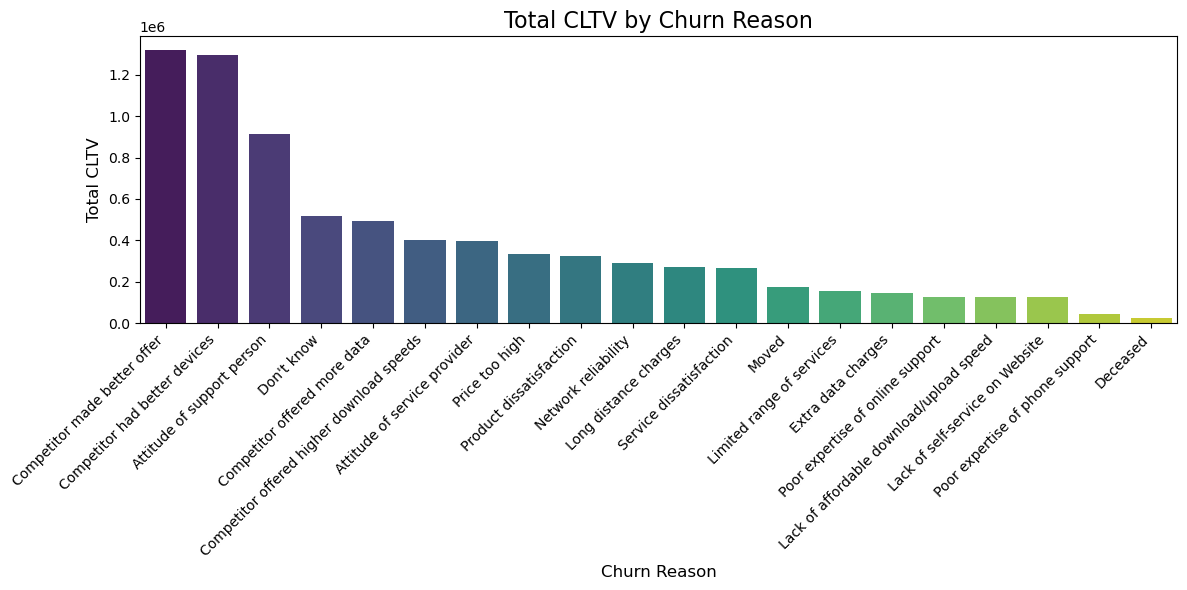

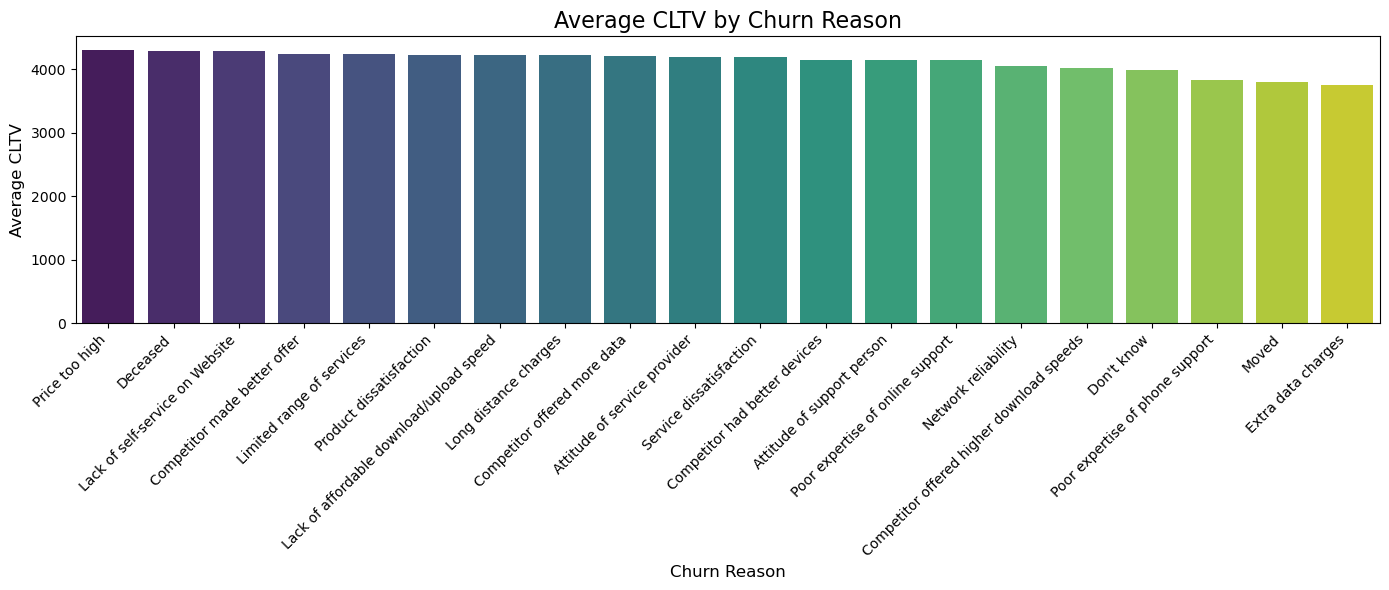

In [7]:

churn_cltv_summary = df_churn.groupby('Churn Reason')['CLTV'].sum().sort_values(ascending=False).reset_index() # grop by using Reason Column

plt.figure(figsize=(12, 6))                       # Total CLTV by Churn Reason 
sns.barplot(data=churn_cltv_summary, x='Churn Reason', y='CLTV', palette="viridis", hue='Churn Reason', dodge=False)
plt.title('Total CLTV by Churn Reason', fontsize=16)
plt.xlabel('Churn Reason', fontsize=12)
plt.ylabel('Total CLTV', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend([], [], frameon=False)  # Hide legend as hue is used only for colors
plt.tight_layout()
plt.show()

mean_cltv_churn = df_churn.groupby('Churn Reason')['CLTV'].mean().reset_index().sort_values(by='CLTV', ascending=False) # Average of churn

plt.figure(figsize=(14, 6))                          # Mean CLTV by Churn Reason with vibrant colors
sns.barplot(data=mean_cltv_churn, x='Churn Reason', y='CLTV', palette="viridis", hue='Churn Reason', dodge=False)
plt.title('Average CLTV by Churn Reason', fontsize=16)
plt.xlabel('Churn Reason', fontsize=12)
plt.ylabel('Average CLTV', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend([], [], frameon=False)  # Hide legend as hue is used only for colors
plt.tight_layout()
plt.show()

mean_cltv_churn.reset_index(drop=True, inplace=True)

As per the data set handbook , CLTV is associated with customer being highly valued while Churn Reason states that why they left the service
Following Analysis responds to understand the relationship between Churing and being Highly Valuable to process further Improvements

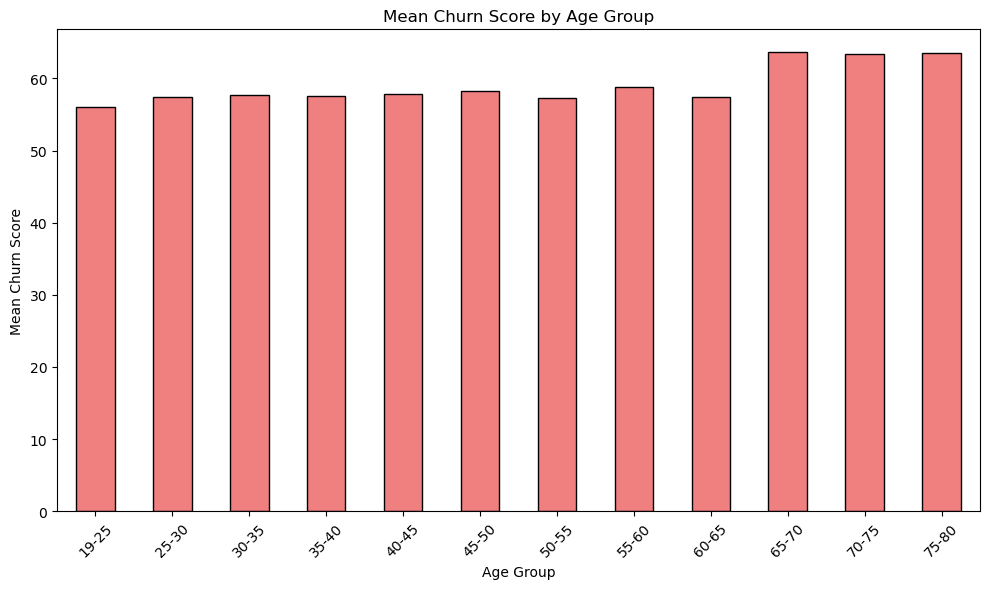

In [8]:
age_bins = [19, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]                                                            # Define age bins and labels
age_labels = ['19-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65-70', '70-75', '75-80']
                                                         
df_telecom['Age Group'] = pd.cut(df_telecom['Age'], bins=age_bins, labels=age_labels, right=False)                          # Create a new column for age groups
mean_churn_by_age_group = df_telecom.groupby('Age Group', observed=False)['Churn Score'].mean()                             #  Calculate the mean Churn Score for each age group, setting observed=False

plt.figure(figsize=(10, 6))                                                                                                 #  Plot the mean Churn Score for each age group
mean_churn_by_age_group.plot(kind='bar', color='lightcoral', edgecolor='black')

plt.title('Mean Churn Score by Age Group')                                                                                 # Adding labels and title
plt.xlabel('Age Group')
plt.ylabel('Mean Churn Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

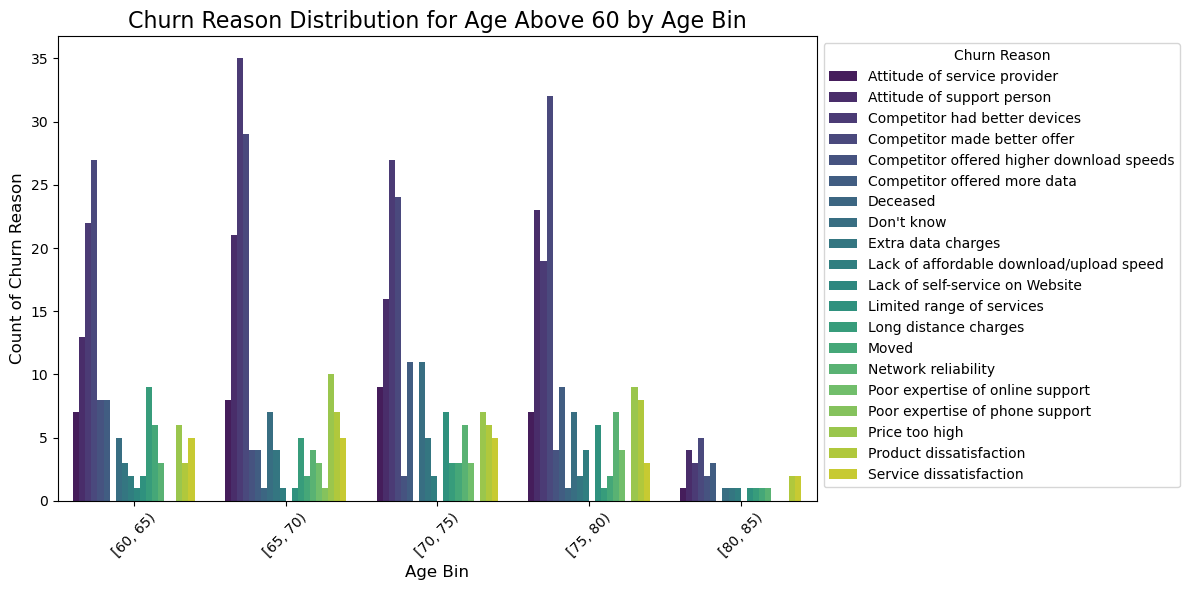

In [9]:
# Filter data for age above 60 and below or equal to 85
df_churn_age_above_60 = df_churn[(df_churn['Age'] > 60) & (df_churn['Age'] <= 85)].copy()  # Use .copy() to avoid modifying a slice of the original DataFrame

# Create age bins of 5 years (from 60 to 85)
age_bins = pd.cut(df_churn_age_above_60['Age'], bins=range(60, 90, 5), right=False)

# Add the age bin as a new column to the dataframe using .loc
df_churn_age_above_60.loc[:, 'Age Bin'] = age_bins

# Group by Churn Reason and Age Bin, count occurrences
churn_reason_age_bins = df_churn_age_above_60.groupby(['Churn Reason', 'Age Bin'], observed=False).size().reset_index(name='Count')

# Plot the data
plt.figure(figsize=(12, 6))
sns.barplot(x='Age Bin', y='Count', hue='Churn Reason', data=churn_reason_age_bins, palette="viridis")

# Customize the plot
plt.title('Churn Reason Distribution for Age Above 60 by Age Bin', fontsize=16)
plt.xlabel('Age Bin', fontsize=12)
plt.ylabel('Count of Churn Reason', fontsize=12)
plt.xticks(rotation=45)

plt.legend(title='Churn Reason', loc='upper left', bbox_to_anchor=(1, 1))                      # legend, outside of the plot

plt.tight_layout()  # Adjust layout for better appearance
plt.show()

Analysis of Value Distribution

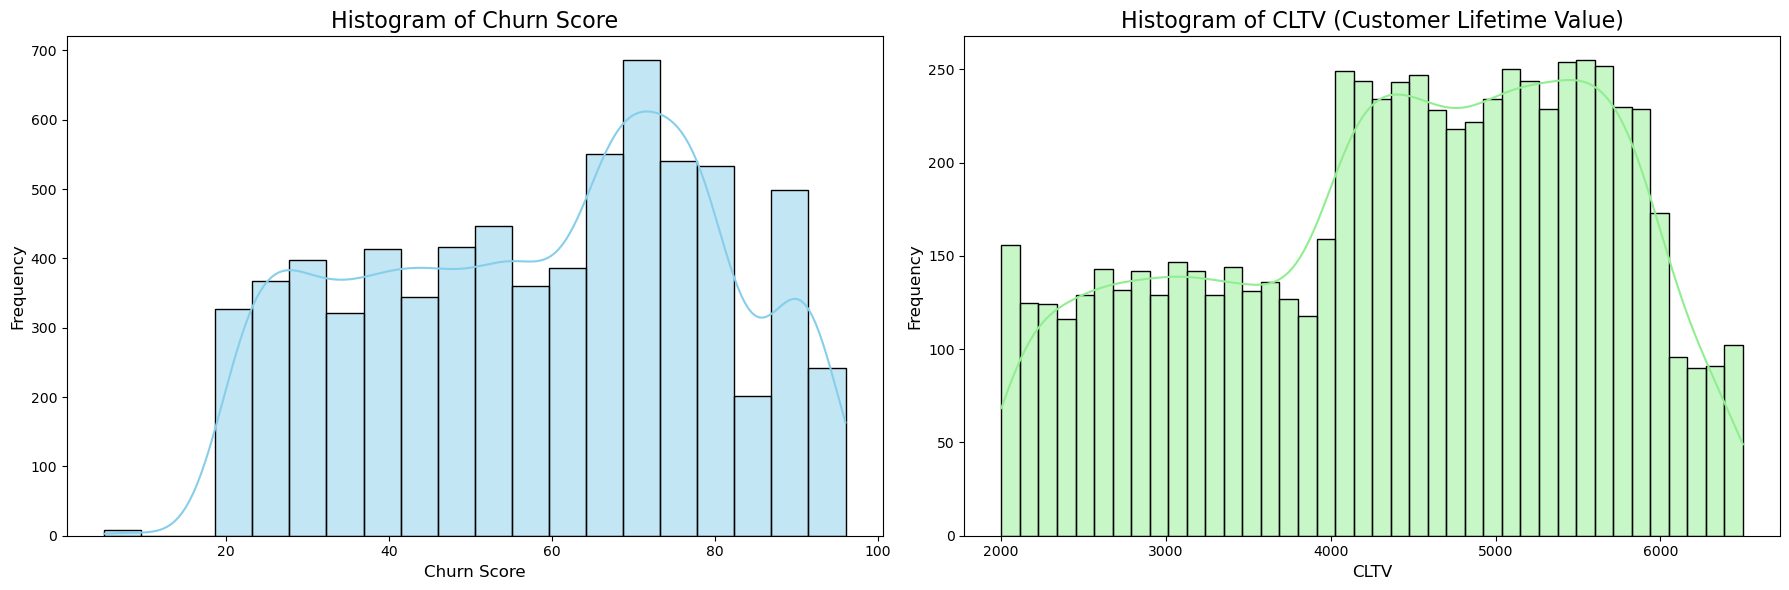

In [10]:
# Define a function to create and display histograms
def plot_histogram(ax, data, column, bins, color, title, xlabel, ylabel):
    sns.histplot(data[column], bins=bins, kde=True, color=color, edgecolor='black', ax=ax)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)

# Create a grid of subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot Churn Score histogram
plot_histogram(axes[0], df_telecom, 'Churn Score', bins=20, color='skyblue', title='Histogram of Churn Score', xlabel='Churn Score', ylabel='Frequency')

# Plot CLTV histogram
plot_histogram(axes[1], df_telecom, 'CLTV', bins=40, color='lightgreen', title='Histogram of CLTV (Customer Lifetime Value)', xlabel='CLTV', ylabel='Frequency')

# Adjust layout for better appearance
plt.tight_layout()
plt.show()

In [11]:
def remove_outliers(df_telecom, column):
    Q1 = df_telecom[column].quantile(0.25)  # 25th percentile
    Q3 = df_telecom[column].quantile(0.75)  # 75th percentile
    IQR = Q3 - Q1  # Interquartile Range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df_telecom[(df_telecom[column] >= lower_bound) & (df_telecom[column] <= upper_bound)]

# Remove outliers for specific columns
df_no_outliers = remove_outliers(df_telecom, 'Churn Score')
df_no_outliers = remove_outliers(df_no_outliers, 'Total Revenue')
df_no_outliers = remove_outliers(df_no_outliers, 'CLTV')


<Figure size 1000x600 with 0 Axes>

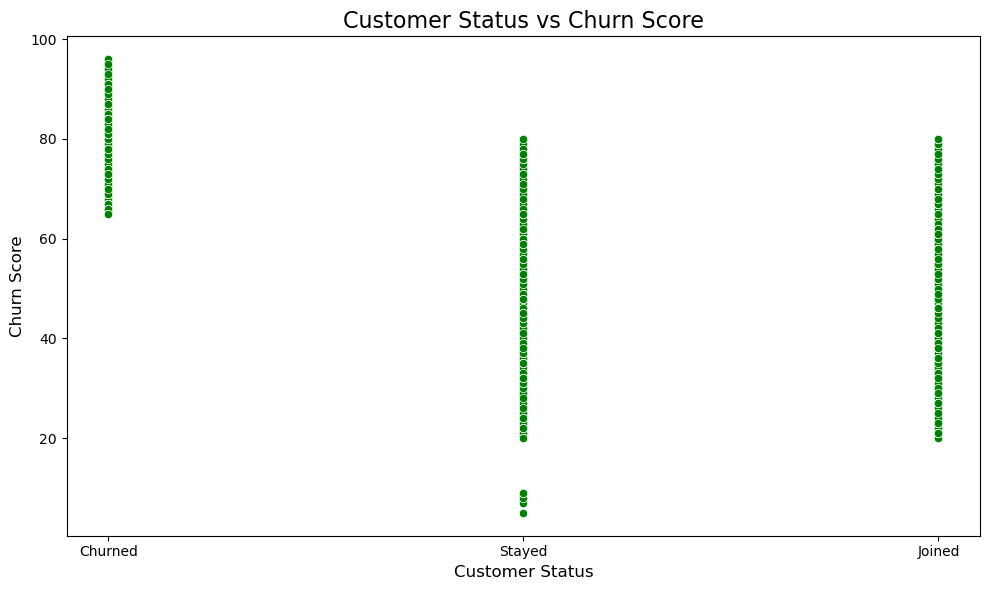

In [12]:
plt.figure(figsize=(10, 6))
# Plot a scatter plot for Customer Status vs Churn Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_telecom['Customer Status'], y=df_telecom['Churn Score'], color='green')

# Customize the plot
plt.title('Customer Status vs Churn Score', fontsize=16)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Churn Score', fontsize=12)
plt.tight_layout()  # Adjust layout for better appearance

plt.show()

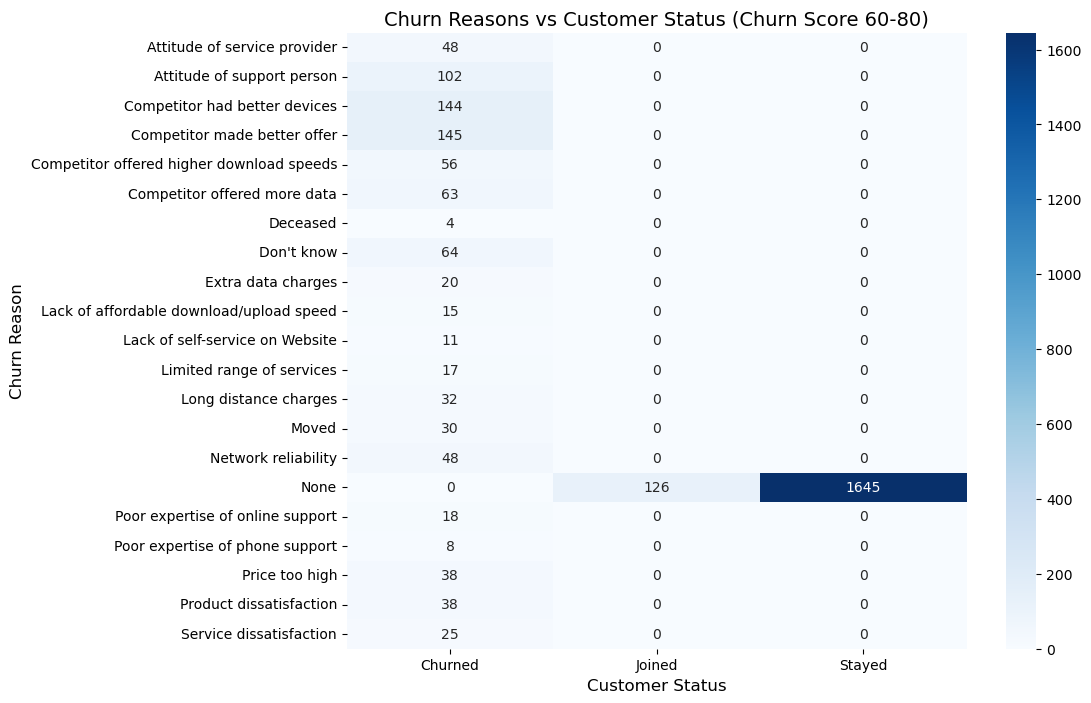

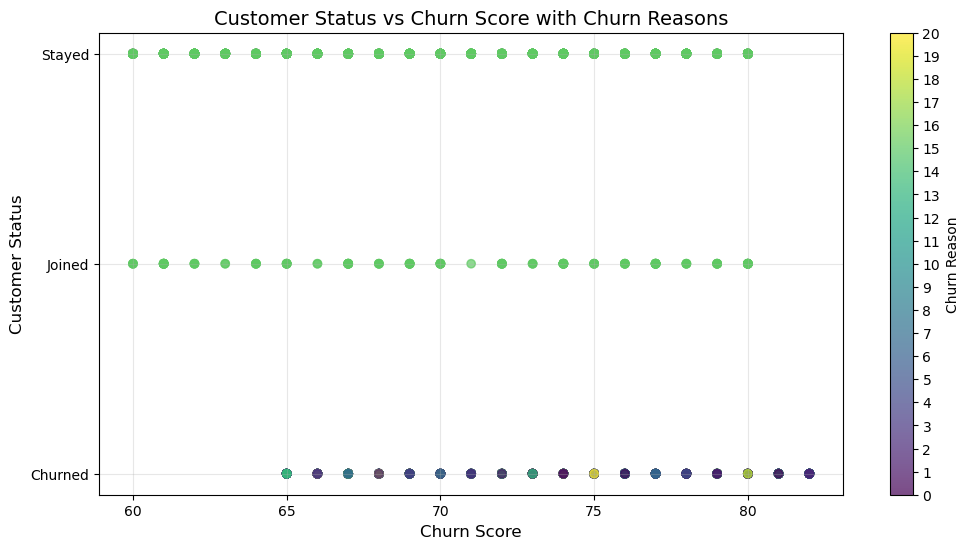

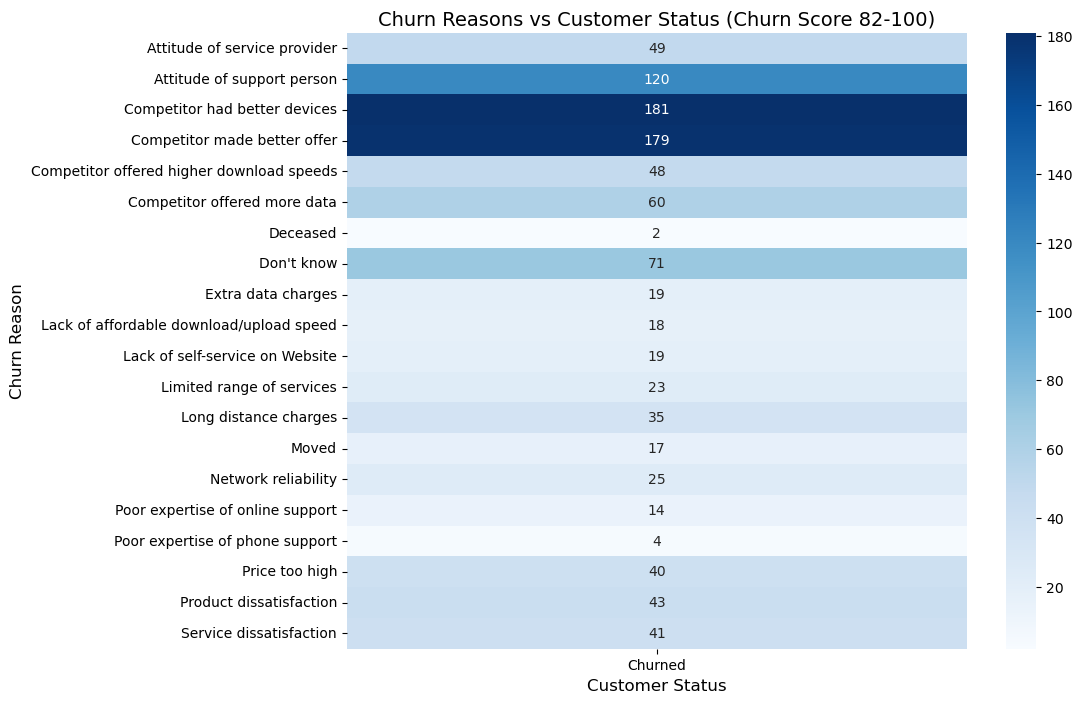

In [13]:
# Filter data for Churn Score between 60 and 80
df_telecom['Churn Reason'] = df_telecom['Churn Reason'].fillna('None') 

filtered_data = df_telecom[(df_telecom['Churn Score'] >= 60) & (df_telecom['Churn Score'] <= 82)]
filtered_data2 = df_telecom[(df_telecom['Churn Score'] >= 82) & (df_telecom['Churn Score'] <= 100)]

# Group by Customer Status and Churn Reason, and count occurrences
grouped_data = filtered_data.groupby(['Customer Status', 'Churn Reason']).size().reset_index(name='Count')
grouped_data2 = filtered_data2.groupby(['Customer Status', 'Churn Reason']).size().reset_index(name='Count')

# Pivot data for heatmap visualization
pivot_data = grouped_data.pivot(index='Churn Reason', columns='Customer Status', values='Count').fillna(0)

# Plot heatmap for Churn Score 60-80
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_data, annot=True, fmt=".0f", cmap="Blues", cbar=True)
plt.title('Churn Reasons vs Customer Status (Churn Score 60-80)', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Churn Reason', fontsize=12)
plt.show()

# Scatter plot for Churn Score and Customer Status, color-coded by Churn Reason
plt.figure(figsize=(12, 6))
scatter = plt.scatter(filtered_data['Churn Score'], 
                       filtered_data['Customer Status'], 
                       c=filtered_data['Churn Reason'].astype('category').cat.codes, 
                       cmap='viridis', alpha=0.7)

plt.colorbar(scatter, ticks=range(filtered_data['Churn Reason'].nunique()), label='Churn Reason')
plt.title('Customer Status vs Churn Score with Churn Reasons', fontsize=14)
plt.xlabel('Churn Score', fontsize=12)
plt.ylabel('Customer Status', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# Pivot data for second heatmap visualization
pivot_data2 = grouped_data2.pivot(index='Churn Reason', columns='Customer Status', values='Count').fillna(0)

# Plot heatmap for Churn Score 82-100
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_data2, annot=True, fmt=".0f", cmap="Blues", cbar=True)
plt.title('Churn Reasons vs Customer Status (Churn Score 82-100)', fontsize=14)
plt.xlabel('Customer Status', fontsize=12)
plt.ylabel('Churn Reason', fontsize=12)
plt.show()

Top three Churn Reasons have been analysed from the above Heatmap

In [23]:
bins = [1,60, 80, 100]  # New binning ranges: 1-20,20-40, 40-60, 60-80, 80-100
labels = [ 'Low','Medium', 'High']  # New labels

# Create a new column 'score_category' based on the 'score' column using the new bins and labels
df_telecom['score_category'] = pd.cut(df_telecom['Churn Score'], bins=bins, labels=labels, right=True)

encoder = LabelEncoder()

columns_to_encode = ['Referred a Friend','Offer', 'Internet Type', 'Internet Service', 'Contract', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
                    'Streaming Music', 'Dependents','Unlimited Data', 'Internet Type', 'Internet Service', 'Contract', 'Online Security', 'Online Backup',
         'Premium Tech Support', 'Satisfaction Score']

# Apply LabelEncoder to each column
for col in columns_to_encode:
    df_telecom[col] = encoder.fit_transform(df_telecom[col])    
    # Display the mapping for each column                         #Commenting the code as if mapping is required it can be uncommented
    # print(f"Label Encoding for {col}:")
    # for original, encoded in zip(encoder.classes_, range(len(encoder.classes_))):
    #     print(f"{original} -> {encoded}")
        

**Encoding to create optimum feature for applying random forest to evaluate the churn score range to take adequate steps before the actual churn happens**

In [15]:
df_score_range = df_telecom
# Define bin ranges for CLTV and Revenue
cltv_bins = range(2000, int(df_score_range['CLTV'].max()) + 1200, 1200)  # Create bins from 2000 with a step of 1000
revenue_bins = range(0, int(df_score_range['Total Revenue'].max()) + 500, 500)  # Create bins from 0 with a step of 500

# Add binned columns
df_score_range['CLTV Range'] = pd.cut(
    df_score_range['CLTV'], 
    bins=cltv_bins, 
    labels=[f"{cltv_bins[i]}-{cltv_bins[i+1]-1}" for i in range(len(cltv_bins)-1)]
)
df_score_range['Revenue Range'] = pd.cut(
    df_score_range['Total Revenue'], 
    bins=revenue_bins, 
    labels=[f"{revenue_bins[i]}-{revenue_bins[i+1]-1}" for i in range(len(revenue_bins)-1)]
)
                                                                                # Encode the ranges into numerical value
df_score_range['CLTV Encoded'] = pd.factorize(df_score_range['CLTV Range'])[0]  # Assign numerical codes to CLTV ranges 
df_score_range['Revenue Encoded'] = pd.factorize(df_score_range['Revenue Range'])[0]  # Assign numerical codes to Revenue ranges

bins = [0, 60, 80, 100]  # Define the bin edges
range_labels = ['0-60','61-80', '81-100']  # Define range labels

df_score_range['Score Range'] = pd.cut(df_telecom['Churn Score'], bins=bins, labels=range_labels, include_lowest=True) # Create the range column

# Create the encoded column
range_encoding = {label: i+1 for i, label in enumerate(range_labels)}  # Create encoding dictionary
df_score_range['Score Encoded'] = df_score_range['Score Range'].map(range_encoding)  # Map range to encoded value

print(df_score_range[['CLTV', 'CLTV Range', 'CLTV Encoded', 'Total Revenue', 'Revenue Range', 'Revenue Encoded', 'Score Range', 'Score Encoded']].head()) # Display the DataFrame with new columns


   CLTV CLTV Range  CLTV Encoded  Total Revenue Revenue Range  \
0  5433  4400-5599             0          59.65         0-499   
1  5302  4400-5599             0        1024.10     1000-1499   
2  3179  2000-3199             1        1910.88     1500-1999   
3  5337  4400-5599             0        2995.07     2500-2999   
4  2793  2000-3199             1        3102.36     3000-3499   

   Revenue Encoded Score Range Score Encoded  
0                0      81-100             3  
1                1       61-80             2  
2                2      81-100             3  
3                3      81-100             3  
4                4       61-80             2  


COMPREHENSIVE VISUALISATIONS FOR REPORT

**RANDOM FOREST CLASSIFER :
This takes several features that incude the satisfaction score and CLTV score range and Revenue Range along with the facilites used by user
This classifer comes as a handy tool to be applied to the incoming customers to get a report to judge a potential increase in Churn Score
It can be regularly trained on the existing customers or whenever there is any change in the Telecom users parametrics.**


In [16]:
X = df_score_range[['Satisfaction Score','Unlimited Data','Offer', 'Internet Type', 'Internet Service', 'Contract', 'Online Security', 'Online Backup',
         'Premium Tech Support', 'Number of Referrals', 'CLTV Encoded', 'Revenue Encoded']]   # Features
y = df_score_range['Score Encoded']                                                           # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)     #Split the data into training and testing sets

rf1 = RandomForestClassifier(n_estimators=100, random_state=42)                               #  Train the Random Forest classifier
rf1.fit(X_train, y_train)
                                                                                             # Make predictions
y_pred = rf1.predict(X_test)

print("Classification Report:")                                                              # Evaluate the model
print(classification_report(y_test, y_pred)) 
 
print("Feature Importances:")                                                                 # Print the feature importances to see which features are most important
print(rf1.feature_importances_)

cm1 = confusion_matrix(y_test, y_pred)
                                                                                            # Print confusion matrix in a simple format with 0, 1, and 2 labels
print("Confusion Matrix:")
print(" Predicted")
print(" 1 2 3 ")           #Header for three Score Ranges
print(f"Actual 0:     {cm1[0]}")
print(f"Actual 1:     {cm1[1]}")
print(f"Actual 3:     {cm1[2]}")


Classification Report:
              precision    recall  f1-score   support

           1       0.65      0.80      0.72      1036
           2       0.38      0.25      0.30       739
           3       0.54      0.58      0.56       338

    accuracy                           0.57      2113
   macro avg       0.53      0.54      0.53      2113
weighted avg       0.54      0.57      0.55      2113

Feature Importances:
[0.23370584 0.02381178 0.09238823 0.05772676 0.00576691 0.05777166
 0.02717861 0.03527736 0.03094386 0.12168838 0.1125278  0.20121281]
Confusion Matrix:
 Predicted
 1 2 3 
Actual 0:     [832 185  19]
Actual 1:     [407 184 148]
Actual 3:     [ 33 110 195]


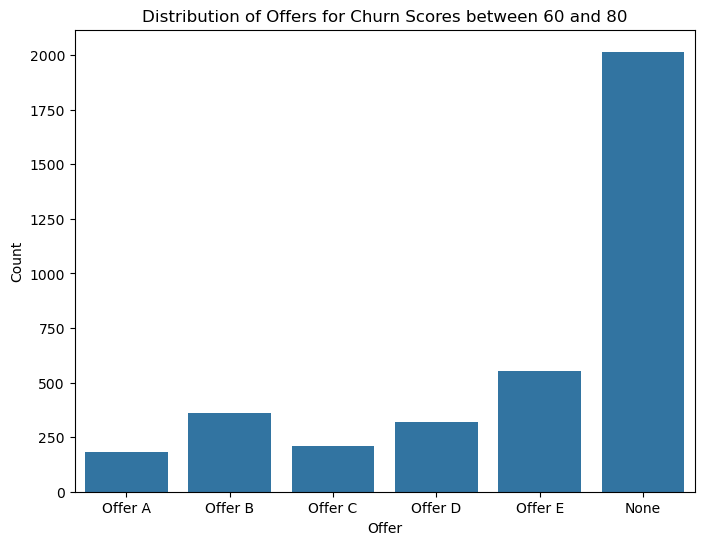

In [17]:

filtered_data = df_telecom[(df_telecom['Churn Score'] >= 60) & (df_telecom['Churn Score'] <= 100)].copy()  #  Filter data for Churn Score between 60 and 80

offer_mapping = {0: 'Offer A', 1: 'Offer B', 2: 'Offer C', 3: 'Offer D', 4: 'Offer E', 5: 'None'} # Reverse the label encoding for 'Offer' using the provided offer_mapping dictionary

filtered_data['Offer_Label'] = filtered_data['Offer'].map(offer_mapping).fillna('Unknown')        

plt.figure(figsize=(8, 6))                                                                       # Create a countplot to see the distribution of offers
sns.countplot(x='Offer_Label', data=filtered_data, order=['Offer A', 'Offer B', 'Offer C', 'Offer D', 'Offer E', 'None'])
plt.title('Distribution of Offers for Churn Scores between 60 and 80')
plt.xlabel('Offer')
plt.ylabel('Count')
plt.show()

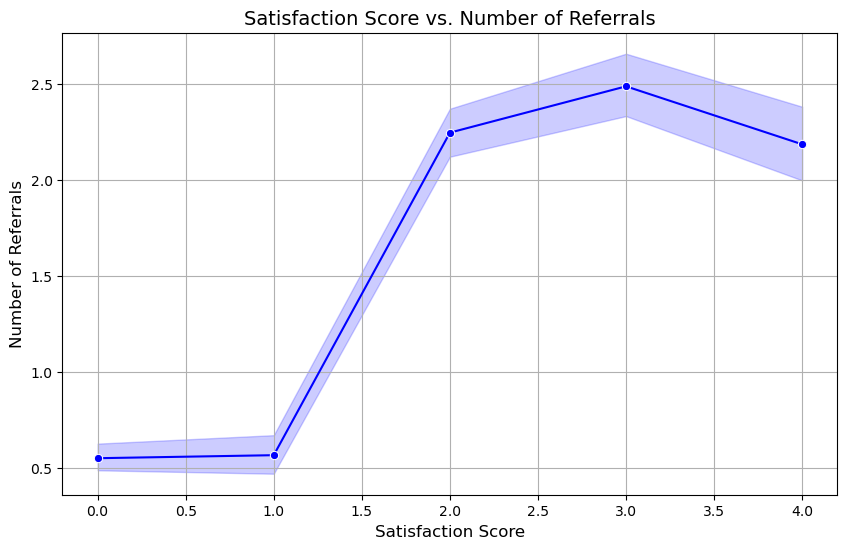

In [18]:
plt.figure(figsize=(10, 6))

sns.lineplot(x='Satisfaction Score', y='Number of Referrals', data=df_telecom, marker='o', color='blue') # Plot the line

plt.title('Satisfaction Score vs. Number of Referrals', fontsize=14)                                    # Customize the plot
plt.xlabel('Satisfaction Score', fontsize=12)
plt.ylabel('Number of Referrals', fontsize=12)
plt.grid(True)
plt.show()

# K-Mean combined: for Customer Segmentation , CLTV vs Revenue, CHurn Score vs Revenue, Churn Score greater than 60 vs Revenue

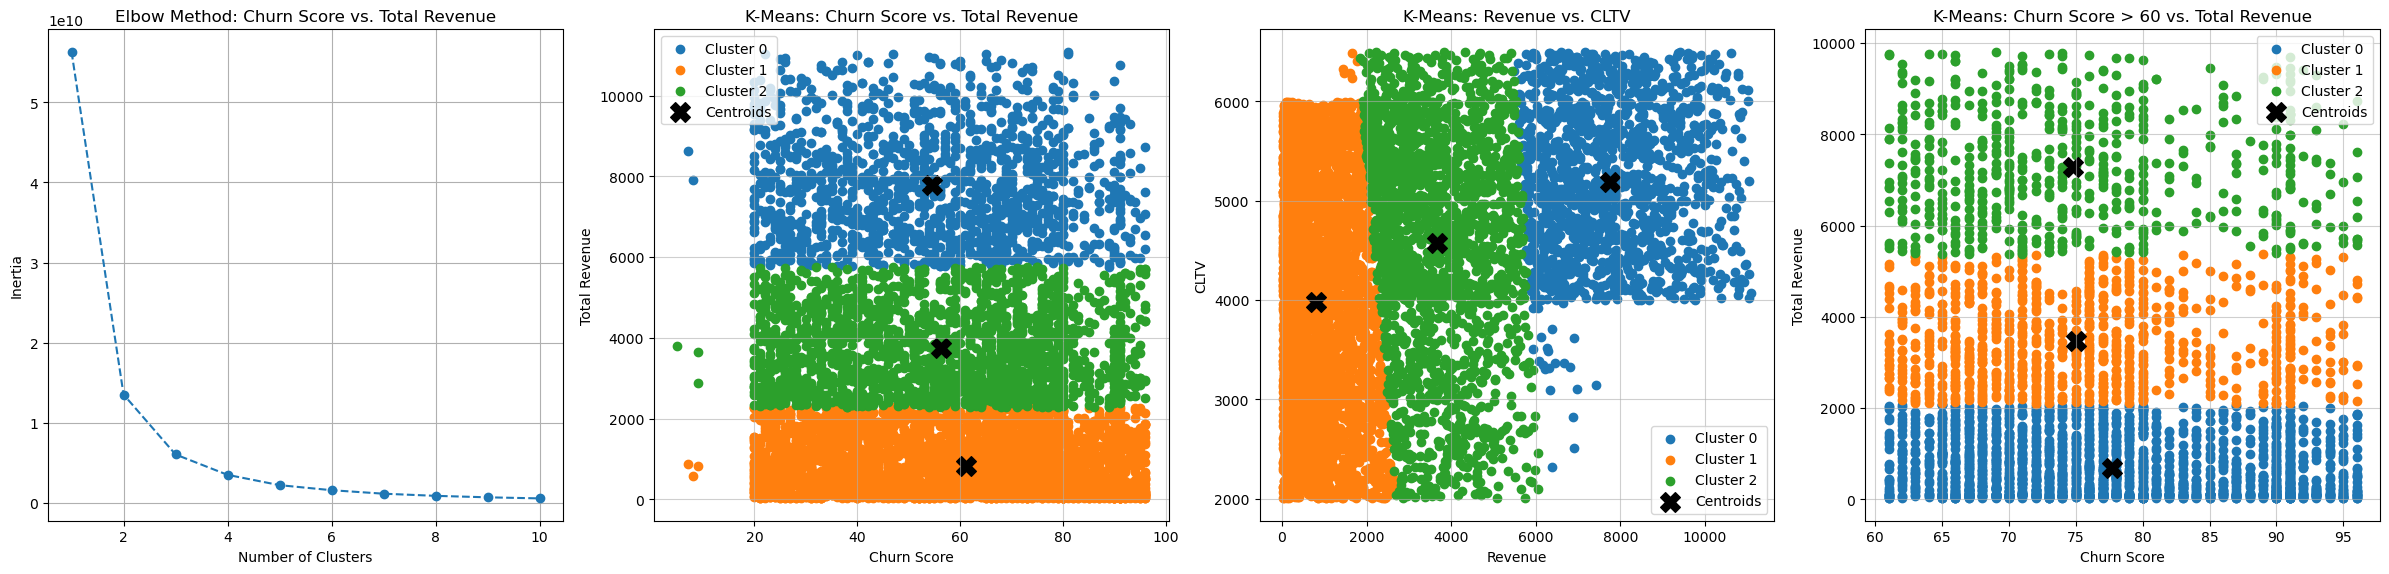

In [19]:

fig, axes = plt.subplots(1, 4, figsize=(24, 6))                              # Adjusting grid size to add elbow plot

X = df_no_outliers[['Churn Score', 'Total Revenue']]                         # Elbow method to find the optimal number of clusters
inertia = []
K_range = range(1, 11)                                                       # Test for 1 to 10 clusters
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

axes[0].plot(K_range, inertia, marker='o', linestyle='--')
axes[0].set_title('Elbow Method: Churn Score vs. Total Revenue')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

kmeans = KMeans(n_clusters=3, random_state=42)                               # Churn Score vs. Total Revenue         
df_no_outliers['Cluster'] = kmeans.fit_predict(X)
axes[1].set_title('K-Means: Churn Score vs. Total Revenue')
for cluster in np.unique(df_no_outliers['Cluster']):
    cluster_data = df_no_outliers[df_no_outliers['Cluster'] == cluster]
    axes[1].scatter(cluster_data['Churn Score'], cluster_data['Total Revenue'], label=f'Cluster {cluster}')
centers = kmeans.cluster_centers_
axes[1].scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
axes[1].set_xlabel('Churn Score')
axes[1].set_ylabel('Total Revenue')
axes[1].legend()
axes[1].grid(alpha=0.6)

X = df_no_outliers[['Total Revenue', 'CLTV']]                               # Revenue vs. CLTV plot 
kmeans = KMeans(n_clusters=3, random_state=42)
df_no_outliers['Cluster'] = kmeans.fit_predict(X)
axes[2].set_title('K-Means: Revenue vs. CLTV')
for cluster in np.unique(df_no_outliers['Cluster']):
    cluster_data = df_no_outliers[df_no_outliers['Cluster'] == cluster]
    axes[2].scatter(cluster_data['Total Revenue'], cluster_data['CLTV'], label=f'Cluster {cluster}')
centers = kmeans.cluster_centers_
axes[2].scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
axes[2].set_xlabel('Revenue')
axes[2].set_ylabel('CLTV')
axes[2].legend()
axes[2].grid(alpha=0.6)

df_filtered = df_telecom[df_telecom['Churn Score'] > 60]                     # Filter for Churn Score > 60 and remove outliers
df_filtered_no_outliers = remove_outliers(df_filtered, 'Churn Score')
df_filtered_no_outliers = remove_outliers(df_filtered_no_outliers, 'Total Revenue')

X = df_filtered_no_outliers[['Churn Score', 'Total Revenue']] # Churn Score > 60 vs. Total Revenue plot
kmeans = KMeans(n_clusters=3, random_state=42)
df_filtered_no_outliers['Cluster'] = kmeans.fit_predict(X)
axes[3].set_title('K-Means: Churn Score > 60 vs. Total Revenue')
for cluster in np.unique(df_filtered_no_outliers['Cluster']):
    cluster_data = df_filtered_no_outliers[df_filtered_no_outliers['Cluster'] == cluster]
    axes[3].scatter(cluster_data['Churn Score'], cluster_data['Total Revenue'], label=f'Cluster {cluster}')
centers = kmeans.cluster_centers_
axes[3].scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
axes[3].set_xlabel('Churn Score')
axes[3].set_ylabel('Total Revenue')
axes[3].legend()
axes[3].grid(alpha=0.6)

plt.tight_layout()
plt.show()

Business Question : 
**How can a telecom company reduce churn and maximize revenue potential by identifying the key drivers of churn, evaluating the impact of current offers, and segmenting customers based on revenue and churn score for targeted retention strategies?**

Our analysis provides a comprehensive understanding of churn drivers and customer retention strategies for the telecom industry.Starting with the churn score distribution, it was observed that customers with scores ranging from 60-82 include a mix of newly joined, active, and staying customers. This overlap highlights a potential risk of churn escalation, necessitating further investigation. A detailed analysis of churn drivers, supported by a heatmap of Churn Reasons vs. Customer Status, revealed critical factors influencing churn. Among the top reasons were **better offers and devices from competitors and negative customer service experiences, particularly the attitude of spokespeople**. In demographic context, Customers of higher age group i.e above 60 had a higher churn score with the same set of reasons. Given that better offers from competitors ranked among the top three reasons,we conducted a visualization of offers. It identified that **Offers B and E** were most prevalent among users with churn scores between 60 and 80 and above as well. However, the majority of users had no ongoing offers, making the lack of offers a key driver of churn.

Further analysis using a line plot suggested a strong correlation between, a higher satisfaction score and a higher count of referrals, underlining the importance of maintaining customer satisfaction. A Random Forest classifier identified key features such as **Satisfaction Score, Number of Referrals, CLTV and Revenue Encoded** as significant predictors of churn. The model achieved an overall accuracy of 59%, which could improve with additional data, particularly from customers with churn scores between 60- 100. To better understand customers with high churn scores (Classes 2 and 3), segementation was done using different parameters, to create tailored retention strategies.

With this objective, **K-means** clustering was applied, clearly segmenting the customer base by churn score and total revenue. The clusters highlighted patterns of churn across revenue levels, particularly among **low- and mid-revenue customers with high churn scores**, who present an opportunity to enhance services and boost retention. Addressing the specific needs of these customers can reduce churn and potentially increase their revenue contribution over time. The segmentation also revealed that across all spending tiers, efforts to reduce churn scores between 60 and 80 are critical. For high-revenue customers, churn can be minimized by offering premium and exclusive services.

The analysis of Customer Lifetime Value alongside revenue identified, Customers with both **high revenue and high CLTV (CLTV above 4000 and revenue above 6000)** were deemed crucial to the business, underscoring the need for retention strategies focused on this segment to drive growth and ensure long-term success. Mid-revenue customers with high CLTV offer potential for upgrades or personalized offers to enhance loyalty and maximize CLTV. Conversely, low-revenue customers may require low-cost retention strategies.

The telecom company can reduce churning by improving services for customers in turn revenue potential among different customer groups. Revaluation and refinement of Offers B and E, ensuring they are competitive and meet customer needs and by providing atleast some offers to consumers who are still loyal without any offer. Proactive steps must be taken with customers in the 60-82 churn score range,especially those who are newly joined or active, to prevent churn escalation.
By addressing these areas, we can reduce churn, retain high-value customers, and drive revenue growth across customer segments.
